# 🔍 AML Detection — Money Laundering Detection Pipeline
**Dataset:** SAML-D (Synthetic Anti-Money Laundering Dataset)

---
### Cara download dataset:
1. Buka https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml
2. Klik tombol **Download** (perlu login Kaggle)
3. Ekstrak file ZIP, lalu taruh file CSV-nya di folder yang sama dengan notebook ini
4. Ganti variabel `DATASET_PATH` di cell berikutnya sesuai nama file CSV kamu
---

## 0. Install Library yang Dibutuhkan

In [5]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn matplotlib seaborn

## 1. Import Library & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import RandomOverSampler
import joblib

# =============================================
# GANTI DENGAN PATH FILE CSV KAMU
DATASET_PATH = r"C:\Users\nelae\Downloads\pencucian_uang_updated (1)\pencucian uang\pencucian uang\SAML-D.csv"
# =============================================

df = pd.read_csv(DATASET_PATH)
print(f'✅ Dataset berhasil dimuat!')
print(f'Shape: {df.shape[0]:,} baris x {df.shape[1]} kolom')
df.head()

✅ Dataset berhasil dimuat!
Shape: 9,504,852 baris x 12 kolom


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


## 2. Eksplorasi Data (EDA)

In [7]:
# Info umum dataset
print('=== Info Dataset ===')
print(df.info())
print()
print('=== Nama Kolom ===')
print(df.columns.tolist())

# Cek missing values
missing = df.isnull().sum()
print()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.any() else '✅ Tidak ada missing values')

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB
None

=== Nama Kolom ===
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

=== Missing Values ===
✅ Tidak ada missing values


Menggunakan kolom target: "Is_laundering"

Distribusi kelas:
  Normal (0): 9,494,979 (99.8961%)
  Mencurigakan (1): 9,873 (0.1039%)


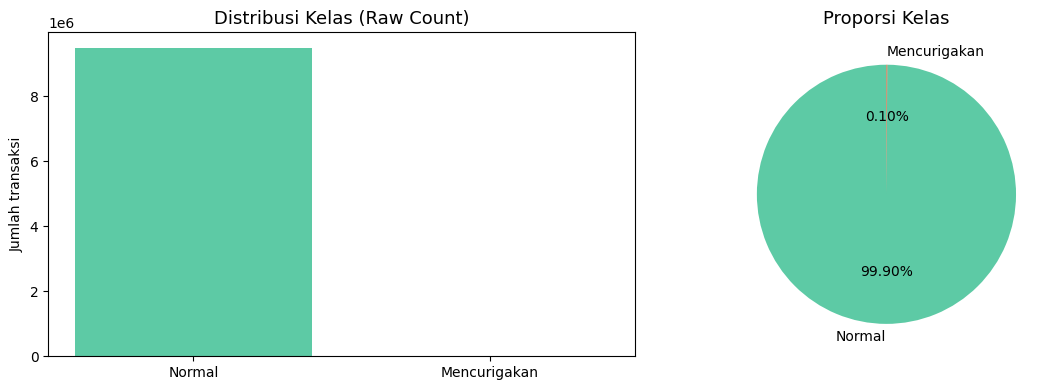

⚠️  Data sangat imbalanced! Perlu ditangani sebelum training.


In [8]:
# Deteksi kolom target secara otomatis
TARGET_COL = 'Is_laundering'
print(f'Menggunakan kolom target: "{TARGET_COL}"')

counts = df[TARGET_COL].value_counts()
pct    = df[TARGET_COL].value_counts(normalize=True) * 100

print(f'\nDistribusi kelas:')
for k in counts.index:
    label = 'Normal' if k == 0 else 'Mencurigakan'
    print(f'  {label} ({k}): {counts[k]:,} ({pct[k]:.4f}%)')

# Plot distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#5DCAA5', '#D85A30']
axes[0].bar(['Normal', 'Mencurigakan'], counts.values, color=colors, edgecolor='none')
axes[0].set_title('Distribusi Kelas (Raw Count)', fontsize=13)
axes[0].set_ylabel('Jumlah transaksi')

axes[1].pie(pct.values, labels=['Normal', 'Mencurigakan'], colors=colors,
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('Proporsi Kelas', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Data sangat imbalanced! Perlu ditangani sebelum training.')

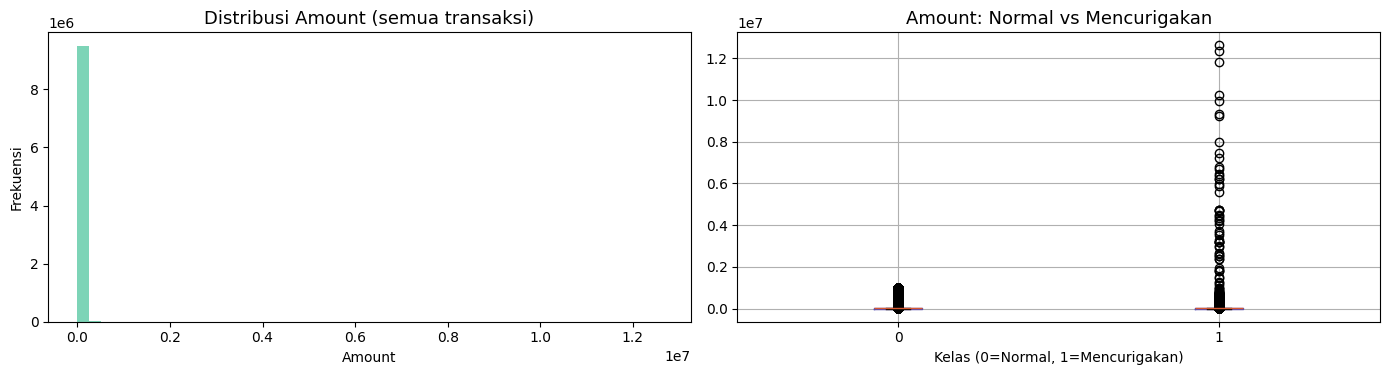

In [9]:
# Distribusi Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=50, color='#5DCAA5', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribusi Amount (semua transaksi)', fontsize=13)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frekuensi')

df.boxplot(column='Amount', by=TARGET_COL, ax=axes[1],
           boxprops=dict(color='#534AB7'), medianprops=dict(color='#D85A30'))
axes[1].set_title('Amount: Normal vs Mencurigakan', fontsize=13)
axes[1].set_xlabel('Kelas (0=Normal, 1=Mencurigakan)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Subsample Data

In [10]:
# Dataset terlalu besar (9.5 juta baris) — subsample dulu agar tidak lambat
# Ambil 200.000 transaksi normal + semua transaksi mencurigakan

df_majority = df[df[TARGET_COL] == 0]
df_minority = df[df[TARGET_COL] == 1]

df_majority_sub = resample(df_majority,
                           n_samples=200_000,
                           random_state=42)

df_sub = pd.concat([df_majority_sub, df_minority]).reset_index(drop=True)
print(f'✅ Subsample selesai!')
print(f'Ukuran setelah subsample: {df_sub.shape[0]:,} baris')
print(f'Distribusi kelas setelah subsample:')
print(df_sub[TARGET_COL].value_counts())

✅ Subsample selesai!
Ukuran setelah subsample: 209,873 baris
Distribusi kelas setelah subsample:
Is_laundering
0    200000
1      9873
Name: count, dtype: int64


## 4. Preprocessing & Feature Engineering

In [11]:
# Buat salinan dari df_sub
df_processed = df_sub.copy()

print('Kolom yang tersedia:')
for col in df_processed.columns:
    print(f'  - {col}: {df_processed[col].dtype}')

Kolom yang tersedia:
  - Time: object
  - Date: object
  - Sender_account: int64
  - Receiver_account: int64
  - Amount: float64
  - Payment_currency: object
  - Received_currency: object
  - Sender_bank_location: object
  - Receiver_bank_location: object
  - Payment_type: object
  - Is_laundering: int64
  - Laundering_type: object


In [12]:
# === FEATURE ENGINEERING ===

# 1. Ekstrak fitur dari kolom waktu
time_candidates = [c for c in df_processed.columns if 'time' in c.lower() or 'date' in c.lower()]
print(f'Kolom waktu ditemukan: {time_candidates}')

for col in time_candidates:
    try:
        df_processed[col] = pd.to_datetime(df_processed[col])
        df_processed[f'{col}_hour']       = df_processed[col].dt.hour
        df_processed[f'{col}_dayofweek']  = df_processed[col].dt.dayofweek
        df_processed[f'{col}_month']      = df_processed[col].dt.month
        df_processed[f'{col}_is_weekend'] = (df_processed[col].dt.dayofweek >= 5).astype(int)
        df_processed.drop(columns=[col], inplace=True)
        print(f'  ✅ Ekstrak fitur waktu dari "{col}"')
    except Exception as e:
        print(f'  ⚠️  Gagal parse "{col}": {e}')

# 2. Flag currency mismatch
currency_cols = [c for c in df_processed.columns if 'currency' in c.lower()]
if len(currency_cols) >= 2:
    df_processed['currency_mismatch'] = (
        df_processed[currency_cols[0]] != df_processed[currency_cols[1]]
    ).astype(int)
    print(f'\n✅ Fitur currency_mismatch dibuat dari {currency_cols}')
    print(f'   Transaksi dengan currency mismatch: {df_processed["currency_mismatch"].sum():,}')

# 3. Fitur agregat per sender
sender_candidates = [c for c in df_processed.columns if 'sender' in c.lower()]
if sender_candidates:
    sender_col = sender_candidates[0]
    sender_stats = df_processed.groupby(sender_col)['Amount'].agg(
        sender_tx_count='count',
        sender_avg_amount='mean',
        sender_std_amount='std',
        sender_max_amount='max'
    ).reset_index()
    df_processed = df_processed.merge(sender_stats, on=sender_col, how='left')
    df_processed['sender_std_amount'] = df_processed['sender_std_amount'].fillna(0)
    df_processed['amount_vs_sender_avg'] = (
        df_processed['Amount'] / (df_processed['sender_avg_amount'] + 1)
    )
    print(f'\n✅ Fitur agregat sender ditambahkan')

print(f'\nTotal kolom setelah feature engineering: {df_processed.shape[1]}')

Kolom waktu ditemukan: ['Time', 'Date']
  ✅ Ekstrak fitur waktu dari "Time"
  ✅ Ekstrak fitur waktu dari "Date"

✅ Fitur currency_mismatch dibuat dari ['Payment_currency', 'Received_currency']
   Transaksi dengan currency mismatch: 26,563

✅ Fitur agregat sender ditambahkan

Total kolom setelah feature engineering: 24


In [13]:
# === DROP DATA LEAKAGE ===
# Laundering_type berisi jenis money laundering — ini bocoran jawaban!
# Di dunia nyata kolom ini tidak akan ada, jadi harus dihapus.
leakage_cols = ['Laundering_type']
existing_leakage = [c for c in leakage_cols if c in df_processed.columns]
if existing_leakage:
    df_processed.drop(columns=existing_leakage, inplace=True)
    print(f'🚫 Drop kolom data leakage: {existing_leakage}')
    print('✅ Model sekarang tidak mencontek!')

# === ENCODING KOLOM KATEGORIKAL ===
categorical_cols = df_processed.select_dtypes(include=['object', 'category']).columns.tolist()

# Drop kolom ID (account number) — tidak informatif sebagai fitur
id_candidates = [c for c in categorical_cols
                 if any(x in c.lower() for x in ['account', 'id'])]
if id_candidates:
    df_processed.drop(columns=id_candidates, inplace=True, errors='ignore')
    print(f'\nDrop kolom ID: {id_candidates}')

# Update list kategorikal
categorical_cols = df_processed.select_dtypes(include=['object', 'category']).columns.tolist()
if TARGET_COL in categorical_cols:
    categorical_cols.remove(TARGET_COL)

print(f'\nKolom yang di-encode: {categorical_cols}')
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = df_processed[col].astype(str).fillna('UNKNOWN')
    df_processed[col] = le.fit_transform(df_processed[col])
    print(f'  ✅ Label encode: {col}')

# Pastikan target numerik
df_processed[TARGET_COL] = pd.to_numeric(df_processed[TARGET_COL], errors='coerce').fillna(0).astype(int)
print(f'\n✅ Encoding selesai. Shape: {df_processed.shape}')

🚫 Drop kolom data leakage: ['Laundering_type']
✅ Model sekarang tidak mencontek!

Kolom yang di-encode: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
  ✅ Label encode: Payment_currency
  ✅ Label encode: Received_currency
  ✅ Label encode: Sender_bank_location
  ✅ Label encode: Receiver_bank_location
  ✅ Label encode: Payment_type

✅ Encoding selesai. Shape: (209873, 23)


In [14]:
# === SPLIT FITUR DAN TARGET ===
X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

print(f'Fitur X: {X.shape}')
print(f'Target y: {y.shape}')
print(f'\nDaftar fitur yang digunakan ({X.shape[1]} fitur):')
for idx, col in enumerate(X.columns):
    print(f'  [{idx}] {col}')

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('\n✅ Scaling selesai (StandardScaler)')

Fitur X: (209873, 22)
Target y: (209873,)

Daftar fitur yang digunakan (22 fitur):
  [0] Sender_account
  [1] Receiver_account
  [2] Amount
  [3] Payment_currency
  [4] Received_currency
  [5] Sender_bank_location
  [6] Receiver_bank_location
  [7] Payment_type
  [8] Time_hour
  [9] Time_dayofweek
  [10] Time_month
  [11] Time_is_weekend
  [12] Date_hour
  [13] Date_dayofweek
  [14] Date_month
  [15] Date_is_weekend
  [16] currency_mismatch
  [17] sender_tx_count
  [18] sender_avg_amount
  [19] sender_std_amount
  [20] sender_max_amount
  [21] amount_vs_sender_avg

✅ Scaling selesai (StandardScaler)


## 5. Split Data Training & Testing

In [15]:
# Stratified split 80% training / 20% testing
# Stratified = proporsi kelas mencurigakan & normal terjaga di kedua bagian
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'✅ Split selesai!')
print(f'  Train : {X_train.shape[0]:,} baris ({y_train.sum():,} mencurigakan)')
print(f'  Test  : {X_test.shape[0]:,} baris ({y_test.sum():,} mencurigakan)')

# Handle imbalance dengan RandomOverSampler pada data TRAIN saja
ros = RandomOverSampler(random_state=42, sampling_strategy=0.1)
X_train_sm, y_train_sm = ros.fit_resample(X_train, y_train)

print(f'\n✅ Oversampling selesai!')
print(f'Distribusi y_train setelah oversampling:')
print(pd.Series(y_train_sm).value_counts())

✅ Split selesai!
  Train : 167,898 baris (7,898 mencurigakan)
  Test  : 41,975 baris (1,975 mencurigakan)

✅ Oversampling selesai!
Distribusi y_train setelah oversampling:
Is_laundering
0    160000
1     16000
Name: count, dtype: int64


## 6. Training Model

In [16]:
# Fungsi evaluasi model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    f1     = f1_score(y_te, y_pred)
    pr_auc = average_precision_score(y_te, y_proba)
    roc    = roc_auc_score(y_te, y_proba)

    print('\n' + '='*50)
    print(f'Model: {name}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  PR-AUC   : {pr_auc:.4f}')
    print(f'  ROC-AUC  : {roc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Mencurigakan']))
    return model, y_pred, y_proba, {'name': name, 'f1': f1, 'pr_auc': pr_auc, 'roc_auc': roc}

In [17]:
# === MODEL 1: Random Forest ===
rf_model, rf_pred, rf_proba, rf_scores = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, max_depth=15,
                           class_weight='balanced', random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_test, y_test
)


Model: Random Forest
  F1-Score : 0.4211
  PR-AUC   : 0.5746
  ROC-AUC  : 0.9072

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95     40000
Mencurigakan       0.30      0.69      0.42      1975

    accuracy                           0.91     41975
   macro avg       0.64      0.80      0.69     41975
weighted avg       0.95      0.91      0.93     41975



In [18]:
# === MODEL 2: XGBoost ===
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw  = neg_count / pos_count
print(f'scale_pos_weight: {scale_pw:.1f}')

xgb_model, xgb_pred, xgb_proba, xgb_scores = evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                  scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
                  eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0),
    X_train_sm, y_train_sm, X_test, y_test
)

scale_pos_weight: 20.3

Model: XGBoost
  F1-Score : 0.2944
  PR-AUC   : 0.6315
  ROC-AUC  : 0.9254

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.80      0.89     40000
Mencurigakan       0.18      0.87      0.29      1975

    accuracy                           0.80     41975
   macro avg       0.58      0.84      0.59     41975
weighted avg       0.95      0.80      0.86     41975



In [19]:
# === MODEL 3: LightGBM ===
lgbm_model, lgbm_pred, lgbm_proba, lgbm_scores = evaluate_model(
    'LightGBM',
    LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                   class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=-1, verbose=-1),
    X_train_sm, y_train_sm, X_test, y_test
)


Model: LightGBM
  F1-Score : 0.3811
  PR-AUC   : 0.6382
  ROC-AUC  : 0.9261

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.88      0.93     40000
Mencurigakan       0.25      0.80      0.38      1975

    accuracy                           0.88     41975
   macro avg       0.62      0.84      0.66     41975
weighted avg       0.95      0.88      0.91     41975



## 7. Visualisasi & Evaluasi

=== Perbandingan Model ===
         name       f1   pr_auc  roc_auc
Random Forest 0.421069 0.574625 0.907196
      XGBoost 0.294385 0.631536 0.925448
     LightGBM 0.381068 0.638168 0.926066


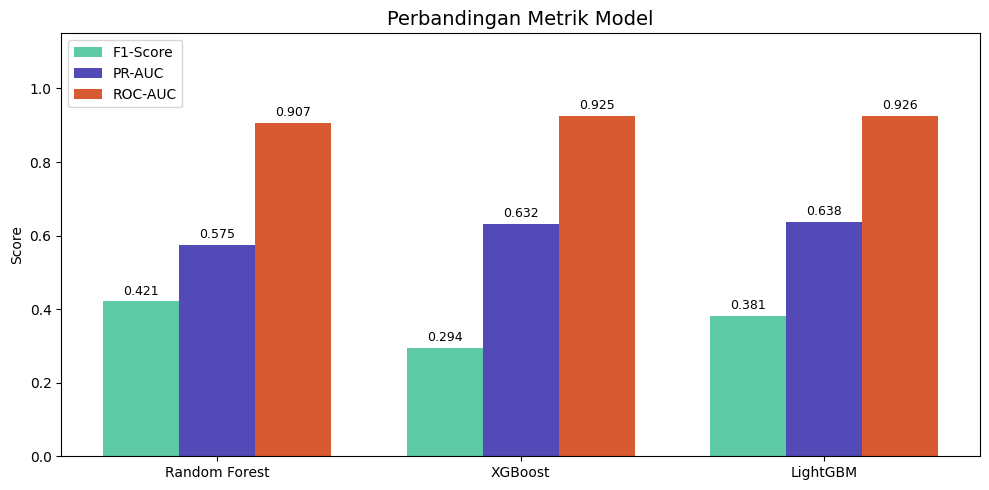

In [20]:
# Perbandingan semua model
results    = [rf_scores, xgb_scores, lgbm_scores]
results_df = pd.DataFrame(results)
print('=== Perbandingan Model ===')
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(results_df))
width  = 0.25
colors = ['#5DCAA5', '#534AB7', '#D85A30']

bars1 = ax.bar(x - width, results_df['f1'],      width, label='F1-Score', color=colors[0])
bars2 = ax.bar(x,          results_df['pr_auc'],  width, label='PR-AUC',  color=colors[1])
bars3 = ax.bar(x + width,  results_df['roc_auc'], width, label='ROC-AUC', color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(results_df['name'])
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Metrik Model', fontsize=14)
ax.legend()
ax.set_ylabel('Score')

for bg in [bars1, bars2, bars3]:
    for b in bg:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

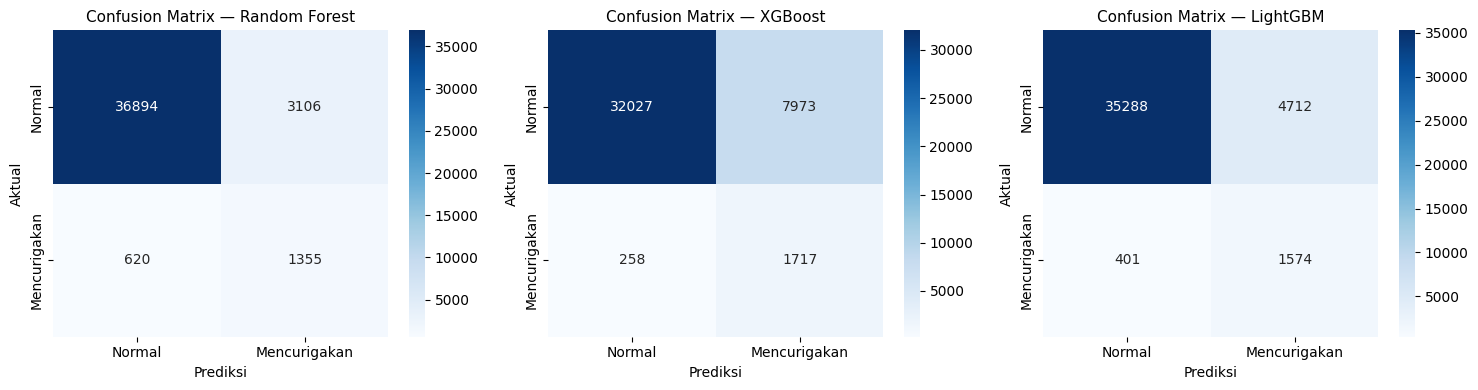

In [21]:
# Confusion Matrix semua model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Random Forest', rf_pred),
    ('XGBoost',       xgb_pred),
    ('LightGBM',      lgbm_pred)
]
for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Mencurigakan'],
                yticklabels=['Normal', 'Mencurigakan'])
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

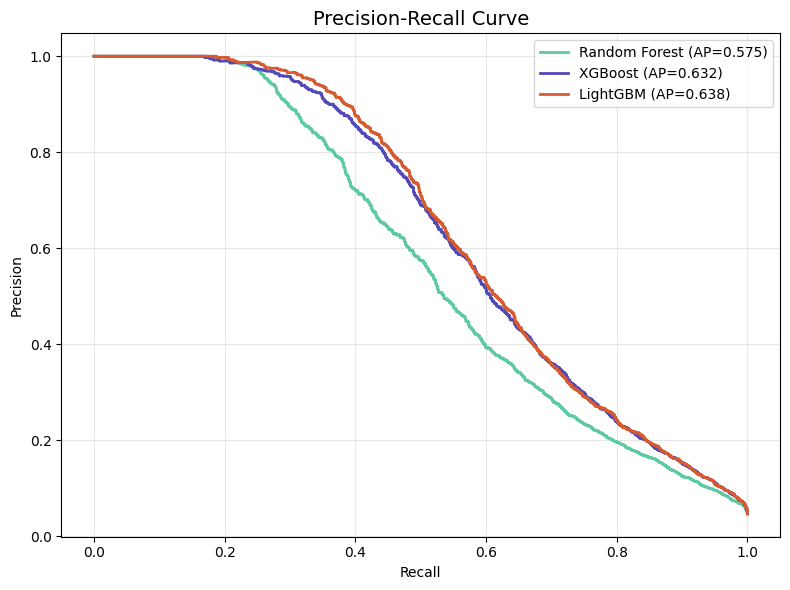

In [22]:
# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba, color in [
    ('Random Forest', rf_proba,   '#5DCAA5'),
    ('XGBoost',       xgb_proba,  '#534AB7'),
    ('LightGBM',      lgbm_proba, '#D85A30')
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

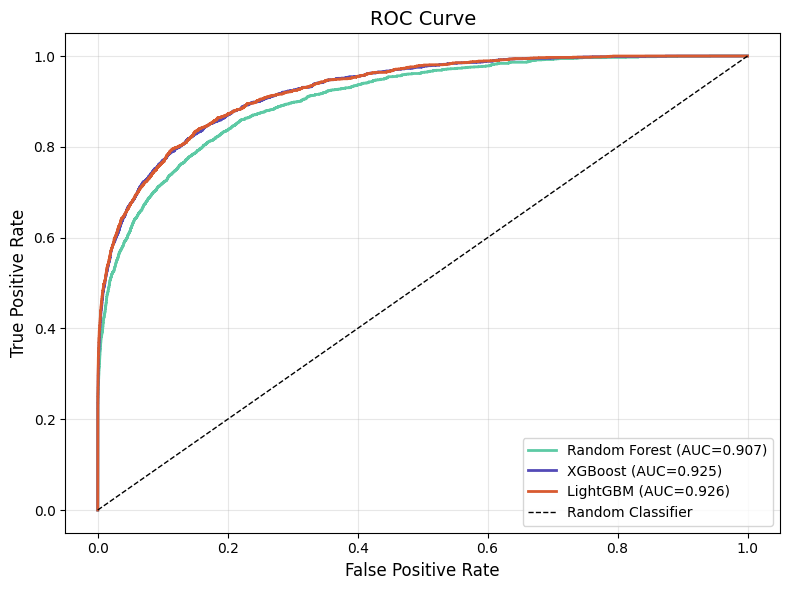

In [23]:
# ROC Curve — semua model
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Random Forest', rf_proba,   '#5DCAA5'),
    ('XGBoost',       xgb_proba,  '#534AB7'),
    ('LightGBM',      lgbm_proba, '#D85A30')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)

# Garis diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

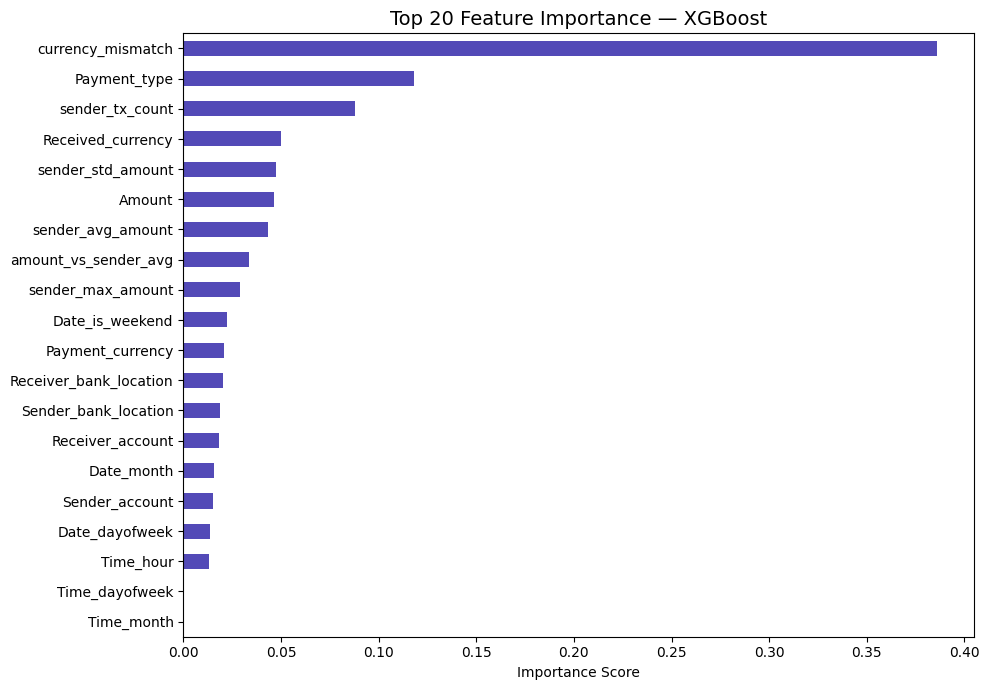


Top 10 fitur terpenting:
currency_mismatch       0.385819
Payment_type            0.118363
sender_tx_count         0.087850
Received_currency       0.049750
sender_std_amount       0.047622
Amount                  0.046363
sender_avg_amount       0.043201
amount_vs_sender_avg    0.033503
sender_max_amount       0.029012
Date_is_weekend         0.022441


In [24]:
# Feature Importance XGBoost — pakai nama kolom asli
fi      = pd.Series(xgb_model.feature_importances_, index=X_scaled.columns)
fi_top20 = fi.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
fi_top20.sort_values().plot.barh(ax=ax, color='#534AB7', edgecolor='none')
ax.set_title('Top 20 Feature Importance — XGBoost', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 fitur terpenting:')
print(fi_top20.head(10).to_string())

## 8. XAI — Explainable AI dengan SHAP

SHAP (SHapley Additive exPlanations) digunakan untuk menjelaskan **mengapa** model memprediksi suatu transaksi sebagai mencurigakan. Ini penting untuk lomba karena model tidak hanya akurat, tapi juga bisa dijelaskan ke stakeholder.

In [25]:
import sys
print(sys.executable)
!pip install shap

c:\Users\nelae\anaconda3\envs\env_baru\python.exe
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.3 MB 4.8 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.3 MB 5.4 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.3 MB 5.6 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.3 MB 6.0 MB/s eta 0:00:02
   ----------------------- ---------------- 7.3/12.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 6.3 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 6.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - --------------------------------

In [26]:
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])

0

In [27]:
import shap

# Inisialisasi JS untuk visualisasi interaktif di notebook
shap.initjs()

# Pakai LightGBM karena paling cepat untuk SHAP TreeExplainer
# Ambil sample 2000 dari test set agar tidak terlalu lama
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)

print("Menghitung SHAP values menggunakan TreeExplainer...")
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_shap)

print(f"✅ SHAP values selesai dihitung!")
print(f"   Shape shap_values: {shap_values.values.shape}")

Menghitung SHAP values menggunakan TreeExplainer...
✅ SHAP values selesai dihitung!
   Shape shap_values: (2000, 22)


=== SHAP Summary Plot ===
Merah = nilai fitur tinggi | Biru = nilai fitur rendah
Kanan = mendorong ke Mencurigakan | Kiri = mendorong ke Normal



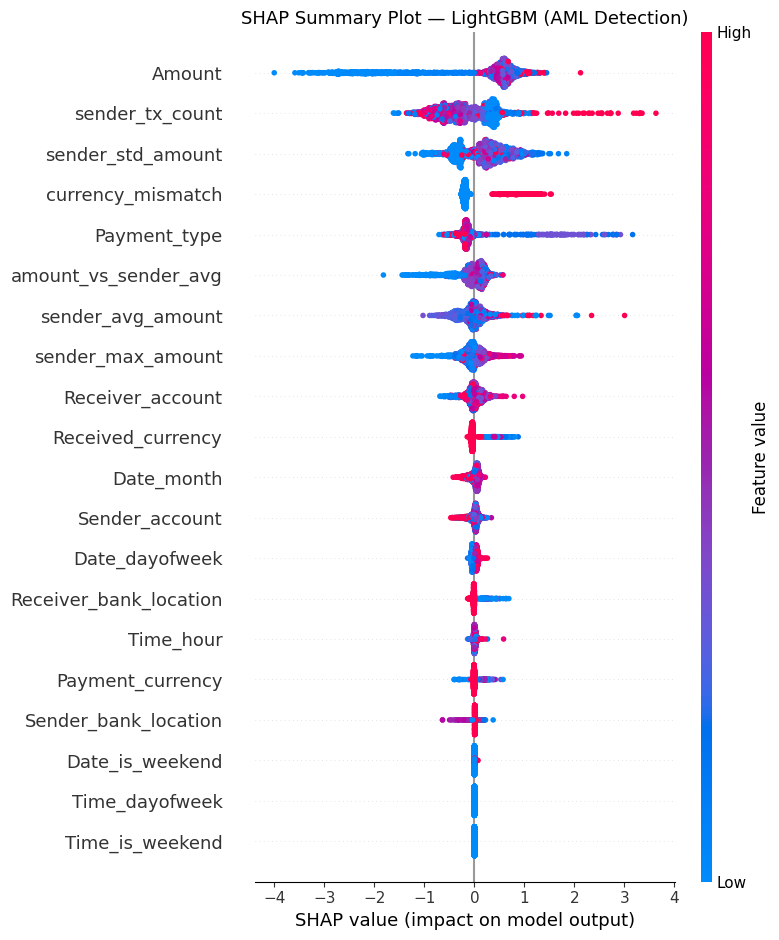

In [28]:
# === PLOT 1: SHAP Summary Plot (Beeswarm) ===
# Menunjukkan fitur mana yang paling berpengaruh dan arah pengaruhnya
# - Warna MERAH  = nilai fitur tinggi
# - Warna BIRU   = nilai fitur rendah
# - Posisi kanan = mendorong prediksi ke "Mencurigakan"
# - Posisi kiri  = mendorong prediksi ke "Normal"

print("=== SHAP Summary Plot ===")
print("Merah = nilai fitur tinggi | Biru = nilai fitur rendah")
print("Kanan = mendorong ke Mencurigakan | Kiri = mendorong ke Normal\n")

shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot — LightGBM (AML Detection)", fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

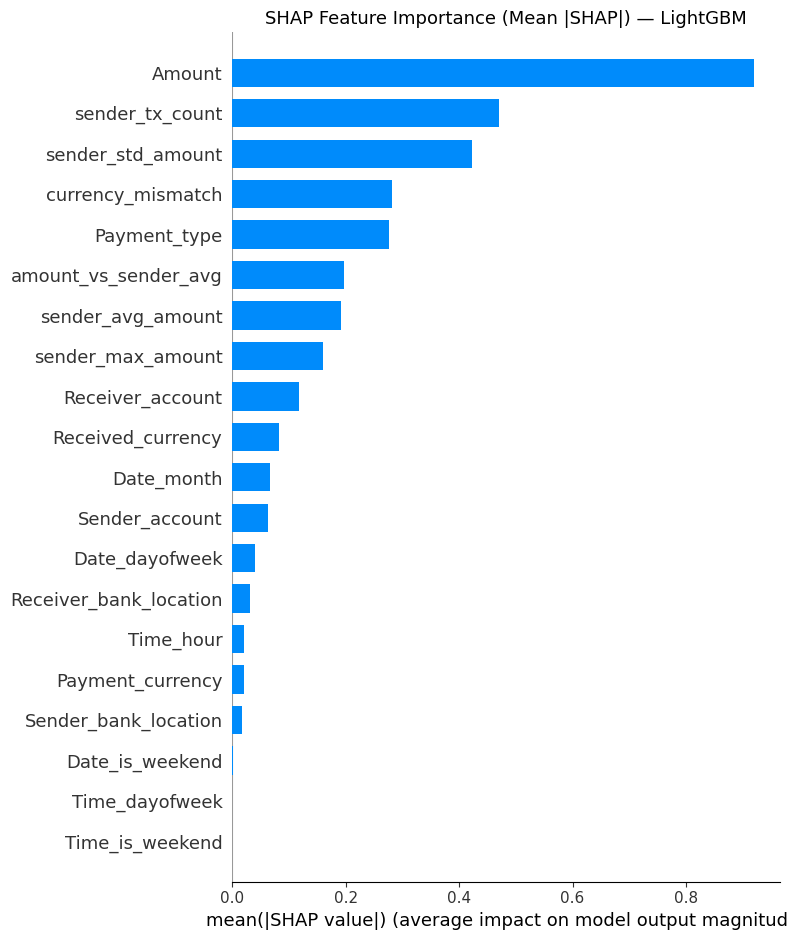

In [29]:
# === PLOT 2: SHAP Bar Plot (Global Feature Importance) ===
# Versi bar chart dari SHAP — lebih mudah dibaca
# Menunjukkan rata-rata |SHAP value| tiap fitur

shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — LightGBM", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Menjelaskan transaksi mencurigakan (index: 204523)


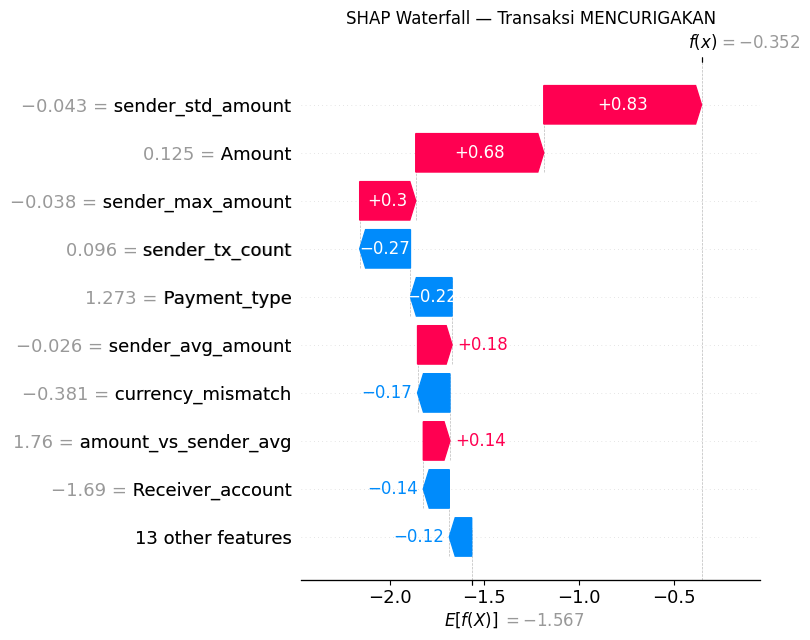

In [30]:
# === PLOT 3: SHAP Waterfall Plot — 1 Transaksi Mencurigakan ===
# Menjelaskan MENGAPA satu transaksi diprediksi mencurigakan
# Setiap bar menunjukkan kontribusi tiap fitur terhadap prediksi akhir

# Cari index transaksi mencurigakan dari X_shap
y_shap = y_test.loc[X_shap.index]
suspicious_idx = y_shap[y_shap == 1].index

if len(suspicious_idx) > 0:
    # Ambil transaksi mencurigakan pertama
    idx_in_shap = X_shap.index.get_loc(suspicious_idx[0])
    print(f"Menjelaskan transaksi mencurigakan (index: {suspicious_idx[0]})")
    shap.waterfall_plot(shap_values[idx_in_shap], show=False)
    plt.title("SHAP Waterfall — Transaksi MENCURIGAKAN", fontsize=12)
    plt.tight_layout()
    plt.savefig('shap_waterfall_suspicious.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Tidak ada transaksi mencurigakan di sample ini, coba perbesar n_samples")

Menjelaskan transaksi normal (index: 141707)


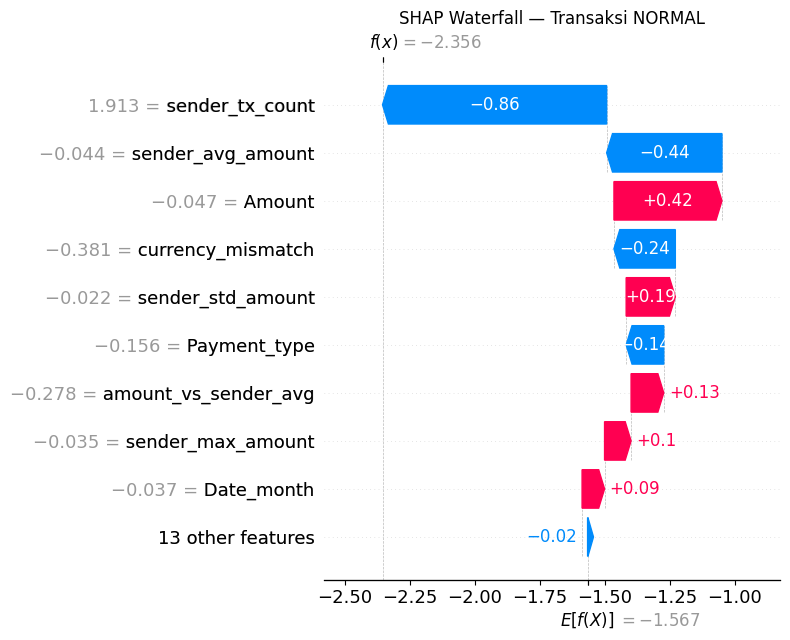

In [31]:
# === PLOT 4: SHAP Waterfall Plot — 1 Transaksi Normal ===
# Untuk perbandingan: kenapa transaksi ini dianggap normal?

y_shap = y_test.loc[X_shap.index]
normal_idx = y_shap[y_shap == 0].index

if len(normal_idx) > 0:
    idx_in_shap = X_shap.index.get_loc(normal_idx[0])
    print(f"Menjelaskan transaksi normal (index: {normal_idx[0]})")
    shap.waterfall_plot(shap_values[idx_in_shap], show=False)
    plt.title("SHAP Waterfall — Transaksi NORMAL", fontsize=12)
    plt.tight_layout()
    plt.savefig('shap_waterfall_normal.png', dpi=150, bbox_inches='tight')
    plt.show()

Dependence plot untuk fitur terpenting: sender_std_amount


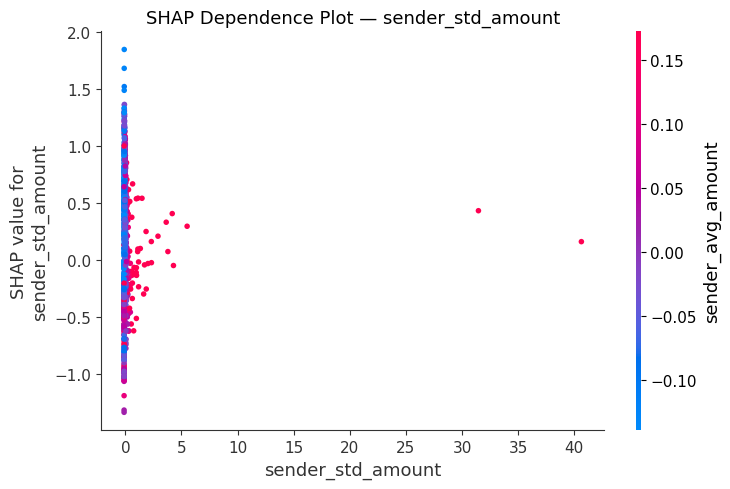


✅ Semua plot SHAP selesai!
File tersimpan: shap_summary_plot.png, shap_bar_plot.png,
                shap_waterfall_suspicious.png, shap_waterfall_normal.png,
                shap_dependence_plot.png


In [32]:
# === PLOT 5: SHAP Dependence Plot — Fitur Terpenting ===
# Menunjukkan hubungan antara nilai fitur dan SHAP value-nya
# Titik tersebar = ada interaksi dengan fitur lain

# Ambil top 1 fitur berdasarkan mean |SHAP|
top_feature = X_shap.columns[shap_values.values[:, :].mean(axis=0).argsort()[::-1][0]]
print(f"Dependence plot untuk fitur terpenting: {top_feature}")

shap.dependence_plot(top_feature, shap_values.values, X_shap, show=False)
plt.title(f"SHAP Dependence Plot — {top_feature}", fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua plot SHAP selesai!")
print("File tersimpan: shap_summary_plot.png, shap_bar_plot.png,")
print("                shap_waterfall_suspicious.png, shap_waterfall_normal.png,")
print("                shap_dependence_plot.png")

## 8. Simpan Model Terbaik

In [33]:
# Pilih model dengan PR-AUC tertinggi
best       = max([rf_scores, xgb_scores, lgbm_scores], key=lambda x: x['pr_auc'])
model_map  = {'Random Forest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgbm_model}
best_model = model_map[best['name']]

print(f'Model terbaik: {best["name"]} (PR-AUC = {best["pr_auc"]:.4f})')

joblib.dump(best_model, 'aml_best_model.pkl')
joblib.dump(scaler,     'aml_scaler.pkl')
print('✅ Model disimpan ke: aml_best_model.pkl')
print('✅ Scaler disimpan ke: aml_scaler.pkl')

Model terbaik: LightGBM (PR-AUC = 0.6382)
✅ Model disimpan ke: aml_best_model.pkl
✅ Scaler disimpan ke: aml_scaler.pkl


## 9. Contoh Prediksi Transaksi Baru

In [34]:
# Demo prediksi menggunakan 1 data dari test set
def predict_transaction(data_row):
    pred  = best_model.predict(data_row.values.reshape(1, -1))[0]
    proba = best_model.predict_proba(data_row.values.reshape(1, -1))[0][1]
    print(f'Prediksi : {"⚠️  MENCURIGAKAN" if pred == 1 else "✅ NORMAL"}')
    print(f'Probabilitas mencurigakan: {proba:.4f} ({proba*100:.2f}%)')
    return pred, proba

sample = X_test.iloc[0]
print(f'Label aktual: {y_test.iloc[0]} ({"Mencurigakan" if y_test.iloc[0]==1 else "Normal"})')
predict_transaction(sample)

Label aktual: 0 (Normal)
Prediksi : ✅ NORMAL
Probabilitas mencurigakan: 0.0106 (1.06%)


(0, 0.010645140794380684)

## 10. Inference Benchmark & Performance Metrics

Section ini mengukur **efisiensi komputasi** model terbaik (LightGBM) secara menyeluruh:

| Metrik | Deskripsi |
|---|---|
| **Model Size on Disk** | Ukuran file `.pkl` dalam MB |
| **Memory Footprint** | Selisih RSS sebelum/sesudah model dimuat ke RAM |
| **Inference Latency** | Waktu rata-rata + P95/P99 per satu transaksi (ms) |
| **Throughput (TPS)** | Jumlah prediksi per detik saat batch inference |
| **CPU & Peak Memory** | Rata-rata CPU (%) & puncak memori selama inferensi |

In [35]:
# ── Pastikan psutil tersedia ──────────────────────────────────────────────
import sys
!{sys.executable} -m pip install psutil -q

import os, time, json, threading, warnings
import numpy as np
import psutil

warnings.filterwarnings('ignore')
print('✅ Library benchmark siap')

✅ Library benchmark siap


In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# HELPER CLASSES & FUNGSI
# ═══════════════════════════════════════════════════════════════════════════

class ResourceMonitor:
    """
    Polling psutil di background thread setiap `interval` detik.
    Mengukur CPU (%) dan RSS memory (MB) selama inferensi berlangsung.
    """
    def __init__(self, interval: float = 0.05):
        self.interval    = interval
        self.cpu_samples : list = []
        self.mem_samples : list = []
        self._running    = False
        self._thread     = None
        self._proc       = psutil.Process(os.getpid())
        self._proc.cpu_percent(interval=None)   # init delta

    def start(self):
        self._running = True
        self._thread  = threading.Thread(target=self._poll, daemon=True)
        self._thread.start()

    def stop(self):
        self._running = False
        if self._thread:
            self._thread.join(timeout=2)

    def _poll(self):
        while self._running:
            self.cpu_samples.append(self._proc.cpu_percent(interval=None))
            self.mem_samples.append(self._proc.memory_info().rss / (1024 ** 2))
            time.sleep(self.interval)

    @property
    def avg_cpu(self):
        valid = [x for x in self.cpu_samples if x > 0]
        return round(sum(valid) / len(valid), 2) if valid else 0.0

    @property
    def peak_memory_mb(self):
        return round(max(self.mem_samples), 2) if self.mem_samples else 0.0


def generate_synthetic_data(n: int, n_features: int = 22) -> np.ndarray:
    """Buat data sintetis acak dengan distribusi mirip data AML."""
    rng = np.random.default_rng(seed=42)
    return np.column_stack([
        rng.integers(1000, 9999,  size=n),   # Sender_account
        rng.integers(1000, 9999,  size=n),   # Receiver_account
        rng.exponential(5000,     size=n),   # Amount
        rng.integers(0, 10,       size=n),   # Payment_currency
        rng.integers(0, 10,       size=n),   # Received_currency
        rng.integers(0, 50,       size=n),   # Sender_bank_location
        rng.integers(0, 50,       size=n),   # Receiver_bank_location
        rng.integers(0, 5,        size=n),   # Payment_type
        rng.integers(0, 24,       size=n),   # Time_hour
        rng.integers(0, 7,        size=n),   # Time_dayofweek
        rng.integers(1, 13,       size=n),   # Time_month
        rng.integers(0, 2,        size=n),   # Time_is_weekend
        rng.integers(0, 24,       size=n),   # Date_hour
        rng.integers(0, 7,        size=n),   # Date_dayofweek
        rng.integers(1, 13,       size=n),   # Date_month
        rng.integers(0, 2,        size=n),   # Date_is_weekend
        rng.integers(0, 2,        size=n),   # currency_mismatch
        rng.integers(1, 200,      size=n),   # sender_tx_count
        rng.exponential(4000,     size=n),   # sender_avg_amount
        rng.exponential(1500,     size=n),   # sender_std_amount
        rng.exponential(20000,    size=n),   # sender_max_amount
        rng.normal(1.0, 0.5,      size=n),   # amount_vs_sender_avg
    ]).astype(np.float64)


print('✅ Helper classes & fungsi benchmark terdefinisi')

✅ Helper classes & fungsi benchmark terdefinisi


In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.1  MODEL SIZE ON DISK  +  MEMORY FOOTPRINT
# ═══════════════════════════════════════════════════════════════════════════

MODEL_PATH  = 'aml_best_model.pkl'
SCALER_PATH = 'aml_scaler.pkl'

# ── Ukuran file di disk ───────────────────────────────────────────────────
model_size_mb  = os.path.getsize(MODEL_PATH)  / (1024 ** 2)
scaler_size_mb = os.path.getsize(SCALER_PATH) / (1024 ** 2)

print('━' * 55)
print('  MODEL SIZE ON DISK')
print('━' * 55)
print(f'  aml_best_model.pkl : {model_size_mb:.3f} MB')
print(f'  aml_scaler.pkl     : {scaler_size_mb:.3f} MB')
print(f'  Total              : {model_size_mb + scaler_size_mb:.3f} MB')

# ── Memory footprint saat load ────────────────────────────────────────────
# Catatan: best_model & scaler sudah ada dari cell sebelumnya.
# Di sini kita ukur ulang selisih RSS untuk akurasi.
proc = psutil.Process(os.getpid())
mem_before = proc.memory_info().rss / (1024 ** 2)

import joblib
_bm = joblib.load(MODEL_PATH)
_sc = joblib.load(SCALER_PATH)

mem_after      = proc.memory_info().rss / (1024 ** 2)
mem_footprint  = max(mem_after - mem_before, 0)

print()
print('━' * 55)
print('  MEMORY FOOTPRINT (RSS delta saat load)')
print('━' * 55)
print(f'  RSS sebelum load   : {mem_before:.2f} MB')
print(f'  RSS sesudah load   : {mem_after:.2f} MB')
print(f'  Footprint model    : {mem_footprint:.2f} MB')
del _bm, _sc   # bebaskan duplikat

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL SIZE ON DISK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  aml_best_model.pkl : 1.015 MB
  aml_scaler.pkl     : 0.002 MB
  Total              : 1.017 MB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MEMORY FOOTPRINT (RSS delta saat load)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RSS sebelum load   : 910.86 MB
  RSS sesudah load   : 910.88 MB
  Footprint model    : 0.01 MB


In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.2  WARM-UP  +  INFERENCE LATENCY (Single-Row)
# ═══════════════════════════════════════════════════════════════════════════

N_WARMUP = 50
N_LAT    = 500

# ── Warm-up: isi JIT cache LightGBM / OpenMP thread-pool ─────────────────
print(f'  Warm-up {N_WARMUP} inferensi...')
wu_data = generate_synthetic_data(N_WARMUP)
for i in range(N_WARMUP):
    best_model.predict(scaler.transform(wu_data[i].reshape(1, -1)))
print('  ✓ Warm-up selesai')

# ── Latency per satu baris ────────────────────────────────────────────────
# time.perf_counter() = resolusi nanosecond (lebih akurat dari time.time())
lat_data = generate_synthetic_data(N_LAT)
latencies_ms = []

for i in range(N_LAT):
    row = lat_data[i].reshape(1, -1)
    t0  = time.perf_counter()
    scaled = scaler.transform(row)
    _      = best_model.predict(scaled)
    t1  = time.perf_counter()
    latencies_ms.append((t1 - t0) * 1_000)

arr = np.array(latencies_ms)

print()
print('━' * 55)
print('  INFERENCE LATENCY (Single-Row, ms)')
print('━' * 55)
print(f'  Jumlah sampel  : {N_LAT}')
print(f'  Mean           : {arr.mean():.4f} ms')
print(f'  Median         : {np.median(arr):.4f} ms')
print(f'  P95            : {np.percentile(arr, 95):.4f} ms  ← target SLA')
print(f'  P99            : {np.percentile(arr, 99):.4f} ms  ← batas atas SLA')
print(f'  Min / Max      : {arr.min():.4f} / {arr.max():.4f} ms')
print(f'  Std Dev        : {arr.std():.4f} ms')

lat_results = {
    'n_samples' : N_LAT,
    'mean_ms'   : round(float(arr.mean()), 4),
    'median_ms' : round(float(np.median(arr)), 4),
    'p95_ms'    : round(float(np.percentile(arr, 95)), 4),
    'p99_ms'    : round(float(np.percentile(arr, 99)), 4),
    'min_ms'    : round(float(arr.min()), 4),
    'max_ms'    : round(float(arr.max()), 4),
    'std_ms'    : round(float(arr.std()), 4),
}

  Warm-up 50 inferensi...
  ✓ Warm-up selesai

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INFERENCE LATENCY (Single-Row, ms)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Jumlah sampel  : 500
  Mean           : 5.1068 ms
  Median         : 3.8615 ms
  P95            : 11.4734 ms  ← target SLA
  P99            : 26.2567 ms  ← batas atas SLA
  Min / Max      : 2.2818 / 36.9607 ms
  Std Dev        : 4.0220 ms


In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.3  TRANSACTION THROUGHPUT (Batch Inference)
# ═══════════════════════════════════════════════════════════════════════════

N_BATCH = 5_000

batch_data   = generate_synthetic_data(N_BATCH)
batch_scaled = scaler.transform(batch_data)

t0    = time.perf_counter()
preds = best_model.predict(batch_scaled)
t1    = time.perf_counter()

elapsed_s    = t1 - t0
tps          = N_BATCH / elapsed_s
fraud_count  = int(preds.sum())
normal_count = N_BATCH - fraud_count

print('━' * 55)
print('  TRANSACTION THROUGHPUT (Batch)')
print('━' * 55)
print(f'  Jumlah sampel      : {N_BATCH:,}')
print(f'  Elapsed time       : {elapsed_s:.4f} s')
print(f'  Throughput (TPS)   : {tps:,.1f} transaksi/detik')
print(f'  Fraud terdeteksi   : {fraud_count:,} ({fraud_count/N_BATCH*100:.1f}%)')
print(f'  Normal terdeteksi  : {normal_count:,}')

tput_results = {
    'n_samples'      : N_BATCH,
    'elapsed_s'      : round(elapsed_s, 6),
    'tps'            : round(tps, 2),
    'fraud_detected' : fraud_count,
    'fraud_rate_pct' : round(fraud_count / N_BATCH * 100, 2),
}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRANSACTION THROUGHPUT (Batch)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Jumlah sampel      : 5,000
  Elapsed time       : 0.0888 s
  Throughput (TPS)   : 56,298.6 transaksi/detik
  Fraud terdeteksi   : 4,221 (84.4%)
  Normal terdeteksi  : 779


In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.4  STRESS TEST + CPU & MEMORY MONITOR
# ═══════════════════════════════════════════════════════════════════════════

N_STRESS = 10_000

stress_data   = generate_synthetic_data(N_STRESS)
stress_scaled = scaler.transform(stress_data)

# ResourceMonitor berjalan di background thread selama inferensi
monitor = ResourceMonitor(interval=0.05)
monitor.start()

t0 = time.perf_counter()
best_model.predict(stress_scaled)
t1 = time.perf_counter()

monitor.stop()

elapsed_stress = t1 - t0

print('━' * 55)
print('  STRESS TEST + CPU & MEMORY MONITOR')
print('━' * 55)
print(f'  Jumlah sampel      : {N_STRESS:,}')
print(f'  Elapsed time       : {elapsed_stress:.4f} s')
print(f'  Throughput (TPS)   : {N_STRESS/elapsed_stress:,.1f} transaksi/detik')
print(f'  Avg CPU usage      : {monitor.avg_cpu:.2f} %')
print(f'  Peak memory (RSS)  : {monitor.peak_memory_mb:.2f} MB')
print(f'  Monitor samples    : {len(monitor.cpu_samples)}')

stress_results = {
    'n_samples'       : N_STRESS,
    'elapsed_s'       : round(elapsed_stress, 6),
    'tps'             : round(N_STRESS / elapsed_stress, 2),
    'avg_cpu_pct'     : monitor.avg_cpu,
    'peak_memory_mb'  : monitor.peak_memory_mb,
}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STRESS TEST + CPU & MEMORY MONITOR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Jumlah sampel      : 10,000
  Elapsed time       : 0.1418 s
  Throughput (TPS)   : 70,529.3 transaksi/detik
  Avg CPU usage      : 239.07 %
  Peak memory (RSS)  : 916.46 MB
  Monitor samples    : 3


In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.5  SIMPAN SEMUA METRIK KE JSON
# ═══════════════════════════════════════════════════════════════════════════

import platform
vm = psutil.virtual_memory()

benchmark_results = {
    'project'       : 'AML Fraud Detection — LightGBM Inference Benchmark',
    'system_info'   : {
        'cpu_logical_cores' : psutil.cpu_count(logical=True),
        'ram_total_gb'      : round(vm.total / 1024**3, 2),
        'platform'          : platform.system(),
        'python_version'    : platform.python_version(),
    },
    'model_on_disk_mb'   : round(model_size_mb, 3),
    'memory_footprint_mb': round(mem_footprint, 2),
    'latency'            : lat_results,
    'throughput_batch'   : tput_results,
    'stress_test'        : stress_results,
}

OUT = 'inference_metrics_updated.json'
with open(OUT, 'w', encoding='utf-8') as f:
    json.dump(benchmark_results, f, indent=2, ensure_ascii=False)

print(f'✅ Hasil benchmark disimpan ke: {OUT}')
print(json.dumps(benchmark_results, indent=2))

✅ Hasil benchmark disimpan ke: inference_metrics_updated.json
{
  "project": "AML Fraud Detection \u2014 LightGBM Inference Benchmark",
  "system_info": {
    "cpu_logical_cores": 8,
    "ram_total_gb": 7.71,
    "platform": "Windows",
    "python_version": "3.12.9"
  },
  "model_on_disk_mb": 1.015,
  "memory_footprint_mb": 0.01,
  "latency": {
    "n_samples": 500,
    "mean_ms": 5.1068,
    "median_ms": 3.8615,
    "p95_ms": 11.4734,
    "p99_ms": 26.2567,
    "min_ms": 2.2818,
    "max_ms": 36.9607,
    "std_ms": 4.022
  },
  "throughput_batch": {
    "n_samples": 5000,
    "elapsed_s": 0.088812,
    "tps": 56298.63,
    "fraud_detected": 4221,
    "fraud_rate_pct": 84.42
  },
  "stress_test": {
    "n_samples": 10000,
    "elapsed_s": 0.141785,
    "tps": 70529.27,
    "avg_cpu_pct": 239.07,
    "peak_memory_mb": 916.46
  }
}


### 📊 Panduan Interpretasi Hasil Benchmark

| Metrik | Nilai Ideal | Cara Baca |
|---|---|---|
| **Mean Latency** | < 5 ms | Makin kecil = makin responsif untuk inferensi real-time |
| **P99 Latency** | < 10 ms | Jaminan 99% transaksi selesai dalam batas ini (SLA) |
| **Memory Footprint** | < 500 MB | Makin kecil = cocok untuk edge/container deploy |
| **Model Size (disk)** | < 50 MB | Penting untuk efisiensi CI/CD dan transfer |
| **TPS (Throughput)** | > 1.000/dtk | Makin besar = mampu handle volume bank besar |
| **Avg CPU** | < 40% | Sisa kapasitas tersedia untuk proses lain |
| **Peak Memory** | < 2× avg | Spike kecil = alokasi memori stabil di produksi |

> **Catatan:** Warm-up diperlukan agar thread-pool OpenMP LightGBM terisi.
> Tanpanya, latency pertama bisa **5–10× lebih lambat** (*cold-start overhead*).
> P95/P99 selalu lebih relevan dari mean untuk menentukan SLA produksi.